In [1]:
# common
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import (
    ColumnTransformer, 
    make_column_selector,
    TransformedTargetRegressor
)

# proprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectPercentile, chi2
from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    QuantileTransformer
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy.sparse import hstack


# models
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, RidgeCV

# metrics
from sklearn.metrics import (
    PredictionErrorDisplay,
    median_absolute_error, 
    r2_score
)
# saving
from tempfile import mkdtemp
from shutil import rmtree
cachedir = mkdtemp()


# configs
sns.set_theme(style="white")

In [2]:

# Load the Train Parquet file for EDA
raw_train_df = pd.read_parquet("../datasets/raw_train_oct_2024.snappy.parquet")

print("Dataset loaded successfully!")
raw_train_df.iloc[:, :15].head(20)  # View first few rows


Dataset loaded successfully!


,stock_item_id,last_date_seen,first_date_seen,days_to_sell,first_retailer_asking_price,last_retailer_asking_price,can_home_deliver,reviews_per_100_advertised_stock_last_12_months,segment,seats,doors,co2_emission_gpkm,top_speed_mph,zero_to_sixty_mph_seconds,engine_power_bhp
0,b6598141a3d1dca4825a72e0f55ddfeb0fb55cabbc14da...,2024-10-12,2024-10-09,3,3695,3695,False,1.0,Independent,5.0,5.0,124.0,107.0,12.7,84.0
1,acdde4604ab932227b68abff979123a3f0b5d26d8b711e...,2024-10-11,2024-09-13,28,18998,18298,False,6.3,Franchise,5.0,5.0,130.0,119.0,None,129.0
2,0d29437822e059c038fc7f6385d9c348ba3727509add9a...,2024-10-05,2024-08-23,43,13990,13990,False,0.2,Independent,5.0,5.0,115.0,124.0,10.0,124.0
3,bbd82c7e47cba47f96ac59c7022ff1ca485c869f660778...,2024-10-15,2024-09-30,15,8174,7990,False,0.3,Independent,4.0,3.0,125.0,126.0,None,123.0
4,2515373efa5d36e0220cd42cc1cea23686e547cad17ca3...,2024-10-07,2024-08-15,53,9450,8750,False,7.3,Independent,5.0,5.0,146.0,120.0,None,123.0
5,cc8b1398b26941edd01b3280dda7a8fa4228a44fca127d...,2024-10-02,2024-09-04,28,7897,7897,False,4.4,Independent,5.0,5.0,158.0,109.0,11.8,110.0
6,10038453f1d28cf2d54764415b16831dbd4729005143c8...,2024-10-26,2024-10-01,25,23500,23000,False,0.7,Franchise,5.0,5.0,147.0,130.0,8.7,148.0
7,768836998ab25ca0284a4ac9aaf0b30c01dd6a1cdb1154...,2024-10-08,2024-09-26,12,10495,10495,False,45.0,Independent,4.0,2.0,124.0,140.0,None,187.0
8,14df89a70ac4058f6f65234a96ff50cfdfc0fcb42ffb4e...,2024-10-02,2024-09-27,5,5250,5250,False,4.6,Independent,5.0,5.0,193.0,110.0,None,148.0
9,ebbe035af17cd4ab562eb71e81da90633cc9b6ee6da588...,2024-10-29,2024-09-23,36,39000,39000,False,0.7,Independent,5.0,5.0,177.0,155.0,None,261.0


In [3]:

# Load the Test Parquet file for trained model testing
raw_test_df = pd.read_parquet("../datasets/raw_test_oct_2024.snappy.parquet")
print("Test Dataset loaded successfully!")
raw_test_df.head()

Test Dataset loaded successfully!


,stock_item_id,last_date_seen,first_date_seen,days_to_sell,first_retailer_asking_price,last_retailer_asking_price,can_home_deliver,reviews_per_100_advertised_stock_last_12_months,segment,seats,...,first_registration_date,attention_grabber,manufacturer_approved,price_indicator_rating,adjusted_retail_amount_gbp,predicted_mileage,number_of_images,first_image_label,advert_quality,postcode_area
0,0789d601c3d1418057fa319a23a163d7712f17961bd775...,2024-10-16,2024-09-30,16,3295,3295,False,22.3,Independent,5.0,...,2011-09-01,ONLY 41506 MILES F/S HISTORY,False,GOOD,3238.0,72777.0,66,FRONT_LEFT,32,DE
1,01f85662b4e5d0739decf02bac0ab97996287bfb1a6720...,2024-10-07,2024-10-04,3,16298,16298,False,11.0,Franchise,5.0,...,2019-11-05,Part-exchange offer now on,False,GOOD,15908.0,45974.0,19,INCONCLUSIVE,45,G
2,4c7daf0ae782e6216219fb368d8725a23abc541d6739de...,2024-10-30,2024-10-01,29,8380,8320,False,11.0,Franchise,5.0,...,2017-04-25,Apple Car Play | Android Auto,False,GREAT,8543.0,52486.0,2,FRONT_RIGHT,63,WN
3,22b562d576693c8db23f563bd55f11b9e25b0d0ca1ac42...,2024-10-30,2024-10-16,14,26990,26990,False,5.3,Independent,5.0,...,2017-06-30,PAN ROOF - IVORY HIDE,False,GREAT,27684.0,65833.0,61,FRONT_RIGHT,60,BL
4,880e451c2032086d78b84fa16cff78e7c643f0d52febf0...,2024-10-19,2024-09-25,24,47999,47949,False,NaN,Franchise,5.0,...,2022-10-31,LOW MILES HIGH SPEC,False,GOOD,48039.0,19381.0,30,FRONT_RIGHT,65,BT


In [4]:
raw_test_df.shape

(31136, 43)

In [5]:
# Sample 30% of the data (replace 0.3 with your desired fraction)
sampled_df = raw_train_df.sample(frac=0.05, random_state=42)

X = sampled_df.drop(columns=['days_to_sell'])  # Drop target from features
y = sampled_df['days_to_sell']  # Target variable

In [6]:
# X_test = raw_test_df.drop(columns=['days_to_sell'])  # Drop target from features
# y_test = raw_test_df['days_to_sell']  # Target variable

## Transformation pipeline utils

In [7]:
# Replace None with Nan Transformer.
def replace_none_with_nan(df: pd.DataFrame) -> pd.DataFrame:
    """Replaces None with np.nan in categorical columns."""
    df = df.copy()
    categorical_cols = df.select_dtypes(include=['object']).columns
    df[categorical_cols] = df[categorical_cols].apply(lambda col: col.map(lambda x: np.nan if x is None else x))
    return df


def drop_cat_features(df: pd.DataFrame) -> pd.DataFrame:
    """Drop features not required"""
    df = df.copy()
    columns_to_drop = ["stock_item_id", "last_date_seen", "first_date_seen", "derivative_id", "first_registration_date"]
    return df.drop(columns=columns_to_drop, errors='ignore')


def convert_columns_to_numeric(df: pd.DataFrame) -> pd.DataFrame:
    """Converts specified object columns to float/numeric type without dropping them."""
    df = df.copy()
    
    convert_columns = ["zero_to_sixty_mph_seconds", "engine_power_bhp", "fuel_economy_wltp_combined_mpg",
                       "battery_usable_capacity_kwh", "length_mm", "insurance_group", "plate"]
    
    # Ensure we only select columns that exist in the DataFrame
    existing_columns = list(set(df.columns) & set(convert_columns))
    
    if existing_columns:  # Only apply conversion if columns exist
        df[existing_columns] = df[existing_columns].apply(pd.to_numeric, errors='coerce')

    return df



# Initialize TfidfVectorizer and CountVectorizer()
# text_vectorizer1 = CountVectorizer()
# text_vectorizer2 = TfidfVectorizer()
# TEXT_COLUMNS = ['attention_grabber', 'make', 'model']

# def apply_text_vectorizer(df: pd.DataFrame) -> hstack:
#     """Applies CountVectorizer to multiple text columns and returns a sparse feature matrix."""
#     transformed_cols = [text_vectorizer1.fit_transform(df[col]) for col in TEXT_COLUMNS]
#     return hstack(transformed_cols) 

In [8]:
DEFAULT_ZERO_NUM_FEATURES = ['battery_range_miles', 'battery_usable_capacity_kwh']
DEFAULT_NON_ZERO_NUM_FEATURES = ['first_retailer_asking_price',
 'last_retailer_asking_price',
 'reviews_per_100_advertised_stock_last_12_months',
 'seats',
 'doors',
 'co2_emission_gpkm',
 'top_speed_mph',
 'zero_to_sixty_mph_seconds',
 'engine_power_bhp',
 'fuel_economy_wltp_combined_mpg',
 'length_mm',
 'boot_space_seats_up_litres',
 'insurance_group',
 'plate',
 'odometer_reading_miles',
 'adjusted_retail_amount_gbp',
 'predicted_mileage',
 'number_of_images',
 'advert_quality']
DEFAULT_HOTENCODE_FEATURES = ['can_home_deliver', 'transmission_type', 'manufacturer_approved', 'segment', 'body_type', 'fuel_type', 'colour', 'first_image_label', 'drivetrain' ]

Data Processing pipelines

In [9]:
# Data preprocessing pipeline
data_preparation_pipeline = Pipeline([
    ('drop_columns', FunctionTransformer(drop_cat_features)), # Drop id and date columns
    ('replace_none', FunctionTransformer(replace_none_with_nan, validate=False)),  # Custom transformer to handle 'None'
    ('convert_2numeric', FunctionTransformer(convert_columns_to_numeric))
])

Numerical pipelines

In [10]:
# Numerical Column transformer
numerical_transformer = ColumnTransformer(
    transformers=[
        ('zero_impute', SimpleImputer(strategy='constant', fill_value=0), DEFAULT_ZERO_NUM_FEATURES), # Zero imputation for specific columns
        ('imputation', SimpleImputer(strategy='mean'), DEFAULT_NON_ZERO_NUM_FEATURES) # Mean imputation for other numerical columns
    ]
)

# Numerical pipeline
numeric_pipeline = Pipeline([
    ('imputer', numerical_transformer),  # Handle missing values
    ('scaler', PowerTransformer(method="yeo-johnson"))  # Scale numeric features
])

Categorical pipelines

In [11]:
# Define ColumnTransformer
categorical_transformer = ColumnTransformer(
    [
        ('he_all', OneHotEncoder(sparse_output=False, min_frequency=0.05, handle_unknown="infrequent_if_exist"), DEFAULT_HOTENCODE_FEATURES),
        ('he_postcode', OneHotEncoder(sparse_output=False, min_frequency=0.01, handle_unknown="infrequent_if_exist"), ["postcode_area"]),
        ('oe_price_indicator', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), ["price_indicator_rating"]),
    ]
)

# Categorical pipeline
categorical_pipeline = Pipeline([
    ('emty_string_imputer', SimpleImputer(strategy='constant', fill_value="").set_output(transform='pandas')),  # Handle missing values for categorical
    ('categorical_encoder', categorical_transformer),
    ("selector", SelectPercentile(chi2, percentile=50))
])

Combined numerical and Categorical Pipeline

In [12]:
columns_preprocessor = ColumnTransformer([
    ('numeric_features', numeric_pipeline, make_column_selector(dtype_include=np.number)),
    #('categorical_features', categorical_pipeline, make_column_selector(dtype_include=["object", "bool"]))
])

Regression models configuration

In [13]:
rng = np.random.RandomState(1)

In [14]:


dt_regr1 = DecisionTreeRegressor()

dt_regr2 = AdaBoostRegressor(
    DecisionTreeRegressor(), n_estimators=300, random_state=rng
)



In [28]:
# random forest models
rf_notrans = RandomForestRegressor()
rf_trans = TransformedTargetRegressor(regressor=rf_notrans,
                                  transformer=QuantileTransformer(output_distribution='normal')
                                 )

In [40]:
log_transformer = QuantileTransformer(output_distribution='normal')
power_transformer = PowerTransformer()

# regr1 = TransformedTargetRegressor(regressor=rf_regr1,
#                                   func=func,
#                                   inverse_func=inverse_func
#                                  )
# regr2 = TransformedTargetRegressor(regressor=rf_regr1,
#                                   transformer=power_transformer
#                                  )

In [41]:
X.shape, y.shape

((5604, 42), (5604,))

In [42]:
X_test.shape, y_test.shape

((1121, 42), (1121,))

In [43]:
# Final pipeline combining the preprocessor and classifier
training_pipeline = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('model_regressor', rf_regr1)
], memory=cachedir)

training_pipeline

NameError: name 'rf_regr1' is not defined

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Print shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4483, 42)
y_train shape: (4483,)
X_test shape: (1121, 42)
y_test shape: (1121,)


In [39]:
training_pipeline.fit(X_train, y_train)

NameError: name 'training_pipeline' is not defined

In [35]:
training_pipeline.score(X_train, y_train)

NameError: name 'training_pipeline' is not defined

In [36]:
training_pipeline.score(X_test, y_test)

NameError: name 'training_pipeline' is not defined

In [21]:
training_pipeline[:-1]

NameError: name 'training_pipeline' is not defined

In [180]:
training_pipeline[:-1].fit_transform(X).shape

(5604, 21)

In [22]:
# target transformation experiment
final_pipeline_notrans = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', rf_notrans)
])

# Final pipeline combining the preprocessor and classifier
final_pipeline_trans = Pipeline([
    ('data_preparation', data_preparation_pipeline),
    ('data_preprocessor', columns_preprocessor),
    ('regressor_pipeline', rf_trans)
])

model_pipeline_notrans = final_pipeline_notrans.fit(X_train, y_train)
model_pipeline_trans = final_pipeline_trans.fit(X_train, y_train)

y_pred_notrans = model_pipeline_notrans.predict(X_test)
y_pred_trans = model_pipeline_trans.predict(X_test)

NameError: name 'rf_trans' is not defined

In [188]:
from sklearn.metrics import r2_score, median_absolute_error, mean_absolute_error, mean_squared_error, mean_squared_log_error

def compute_score(y_true, y_pred):
    return {
        "R2": f"{r2_score(y_true, y_pred):.3f}",
        "MedAE": f"{median_absolute_error(y_true, y_pred):.3f}",
    }


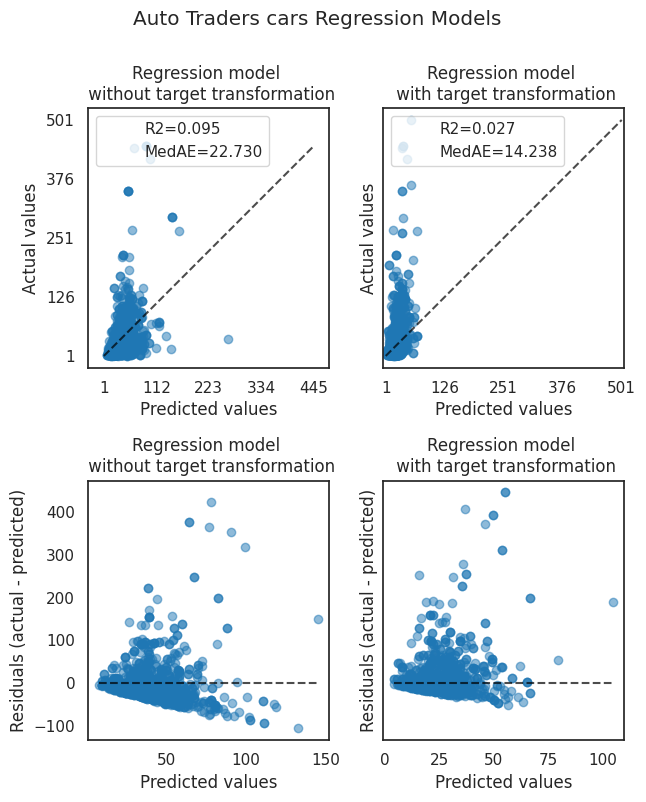

In [189]:

f, (ax0, ax1) = plt.subplots(2, 2, sharey="row", figsize=(6.5, 8))

# plot the actual vs predicted values
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_notrans,
    kind="actual_vs_predicted",
    ax=ax0[0],
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_trans,
    kind="actual_vs_predicted",
    ax=ax0[1],
    scatter_kwargs={"alpha": 0.5},
)

# Add the score in the legend of each axis
for ax, y_pred in zip([ax0[0], ax0[1]], [y_pred_notrans, y_pred_trans]):
    for name, score in compute_score(y_test, y_pred).items():
        ax.plot([], [], " ", label=f"{name}={score}")
    ax.legend(loc="upper left")

ax0[0].set_title("Regression model \n without target transformation")
ax0[1].set_title("Regression model \n with target transformation")

# plot the residuals vs the predicted values
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_notrans,
    kind="residual_vs_predicted",
    ax=ax1[0],
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_trans,
    kind="residual_vs_predicted",
    ax=ax1[1],
    scatter_kwargs={"alpha": 0.5},
)
ax1[0].set_title("Regression model \n without target transformation")
ax1[1].set_title("Regression model \n with target transformation")

f.suptitle("Auto Traders cars Regression Models", y=1.0)
plt.tight_layout()
plt.show()